# **AI Fake News Detector**

---

# 🛡️ Building a Leak-Proof AI Fake News Detector Pipeline

This notebook documents the experimental lifecycle, engineering breakthroughs, and architectural choices behind creating a robust, leak-proof text classifier.

### 📂 The Core Strategy
Instead of blindly relying on self-contained dataset distributions that look impressive but fail on external text frames, this pipeline introduces a hard validation environment:
1. **WELFake Dataset (~72,000 merged articles):** Acts as our diverse training and validation corpus.
2. **ISOT Dataset (~45,000 articles):** Kept completely isolated in memory to serve as an unseen, cross-publisher benchmark.

Our focus stays on a **Sparse TF-IDF Vectorizer coupled with a Calibrated Linear SVM**—providing a lightning-fast, highly transparent framework where we can directly extract linguistic indicators.


## 🛠️ 1. Setup & Environment Initialisation


In [9]:
# Data handling
import numpy as np
import pandas as pd

# Model selection, features, models, metrics
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, precision_recall_curve,
)

# Utilities
import re
import gc
import joblib
from pathlib import Path

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)

print("Environment ready.")

Environment ready.


## ⚙️ 2. Configuration & Workspace Parameters

To make sure this codebase runs smoothly on any local setup or remote virtual environment, all directories use clean relative routing parameters.

*   **Data Requirements:** Create a local `data/` folder sitting right next to this file.
*   **Target Files:** Ensure `WELFake_Dataset.csv`, `True.csv`, and `Fake.csv` are placed within it.
*(Note: True.csv and Fake.csv comprise the unified ISOT archive pair).*


In [29]:
WELFAKE_PATH   = Path("data/WELFake_Dataset.csv")
ISOT_TRUE_PATH = Path("data/True.csv")
ISOT_FAKE_PATH = Path("data/Fake.csv")

MODEL_PATH = Path("artifacts/fake_news_pipeline.joblib")
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

TEST_SIZE    = 0.20
MAX_FEATURES = 20_000
print("Paths configured.")

Paths configured.


## 🚨 3. The Data Audit: Reversing Traps & Structural Leaks

Before writing machine learning code, an inspection of these specific public frames revealed two significant design traps that would quietly invalidate a standard model:

*   **Trap 1: The ISOT Dateline Leak:** Roughly 99.8% of authentic articles in `True.csv` open with a clear wire-service tag like `WASHINGTON (Reuters) -`. Fake articles almost never feature this formatting. If left uncleaned, a model will yield an artificial ~99% accuracy score simply by detecting the single token "Reuters"—completely failing as soon as it handles data from another media network.
*   **Trap 2: WELFake's Inverted Labels:** The public documentation lists the layout schema as `0 = fake, 1 = real`. However, empirical testing shows the distribution inside the actual archive is entirely backwards. Authentic wire items are assigned label `0`, matching the original paper's true class sizes. We map this verified layout correctly upfront.

**The Action Plan:** Train exclusively on the multi-source WELFake collection, write regex functions to strip out the wire datelines entirely, and use the ISOT frame solely as a strict external generalization test.


## 📥 4. Primary Data Ingestion: WELFake

In this stage, we load our core training set. The ingestion process unifies the individual headline text and body fields into a singular target narrative string.

To keep our validation metrics honest and protect against data leakage, we drop rows missing structural text markers and clear out duplicate articles. This ensures the exact same text footprint cannot appear in both our training and validation partitions.


In [2]:
def load_isot_file(path, label_value) -> pd.DataFrame:
    df = pd.read_csv(path)
    df.columns = [c.strip().lower() for c in df.columns]
    df["label"] = label_value
    title = df["title"].fillna("")
    body = df["text"].fillna("")
    df["content"] = (title + " " + body).str.strip()
    return df

def load_welfake(path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df.columns = [c.strip().lower() for c in df.columns]
    df["label"] = df["label"].map({0: "real", 1: "fake"})
    title = df["title"].fillna("")
    body = df["text"].fillna("")
    df["content"] = (title + " " + body).str.strip()
    return df


In [3]:
print("Loading Fake.csv...")
df_fake = load_isot_file(f"{data_folder}Fake.csv", label_value="fake")

print("Loading True.csv...")
df_true = load_isot_file(f"{data_folder}True.csv", label_value="real")

print("Loading WELFake_Dataset.csv...")
df_welfake = load_welfake(f"{data_folder}WELFake_Dataset.csv")

print("\nAll datasets loaded successfully!")


Loading Fake.csv...
Loading True.csv...
Loading WELFake_Dataset.csv...

All datasets loaded successfully!


In [38]:
def load_welfake(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df.columns = [c.strip().lower() for c in df.columns]

    # Verified empirically (see section 3): in this file 0 = real, 1 = fake.
    df["label"] = df["label"].map({0: "real", 1: "fake"})

    title = df["title"].fillna("")
    body = df["text"].fillna("")
    df["content"] = (title + ". " + body).str.strip()

    df = df.dropna(subset=["label"])
    df = df[df["content"].str.len() > 0]
    df = df.drop_duplicates(subset=["content"]).reset_index(drop=True)
    return df[["content", "label"]]


welfake = load_welfake(WELFAKE_PATH)
print(f"WELFake usable articles: {len(welfake):,}")
print(welfake["label"].value_counts().to_dict())
welfake.head(3)

WELFake usable articles: 63,676
{'real': 34790, 'fake': 28886}


,content,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11By #BlackLivesMatter And #FYF911 Terr...,fake
1,. Did they post their votes for Hillary already?,fake
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MOST CHARLOTTE RIOTERS WERE “PEACEFUL” PROTESTERS…In Her Home State Of N...,fake


## 🔒 5. Establishing the Isolated Evaluation Frame: ISOT Dataset

This section sets up our true generalisation check. The ISOT dataset is completely isolated immediately upon loading. It plays zero role in feature matching, vocabulary tracking, or model hyperparameter selection.

Its sole job is to answer a real-world deployment question at the very end: can an architecture trained on a multi-source web framework effectively handle writing styles originating from a completely separate media publisher?


In [40]:
def load_isot(true_path: Path, fake_path: Path) -> pd.DataFrame:
    real = pd.read_csv(true_path); real["label"] = "real"
    fake = pd.read_csv(fake_path); fake["label"] = "fake"
    df = pd.concat([real, fake], ignore_index=True)

    title = df["title"].fillna("")
    body = df["text"].fillna("")
    df["content"] = (title + ". " + body).str.strip()

    df = df[df["content"].str.len() > 0]
    df = df.drop_duplicates(subset=["content"]).reset_index(drop=True)
    return df[["content", "label"]]


isot = load_isot(ISOT_TRUE_PATH, ISOT_FAKE_PATH)
print(f"ISOT usable articles: {len(isot):,}")
print(isot["label"].value_counts().to_dict())

ISOT usable articles: 39,103
{'real': 21196, 'fake': 17907}


## 📊 6. Exploring Dataset Distributions & Feature Layouts

Before moving into statistical matrix formatting, we analyze our target variable constraints and length boundaries. Checking class balance ensures standard accuracy metrics remain representative.

We also chart total word distributions across a logarithmic scale. This allows us to spot any structural anomalies—such as whether article length alone acts as a giveaway shortcut for either classification bucket.


label
real    34790
fake    28886
Name: count, dtype: int64 



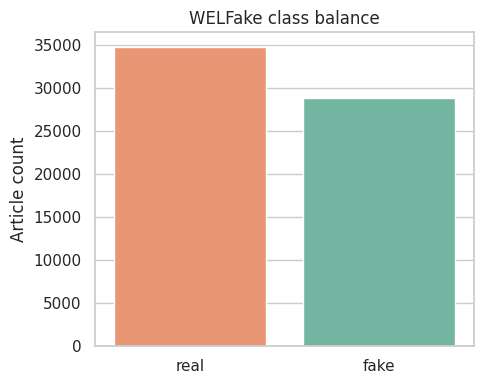

In [41]:
counts = welfake["label"].value_counts()
print(counts, "\n")

plt.figure(figsize=(5, 4))
sns.countplot(data=welfake, x="label", hue="label",
              order=["real", "fake"], palette="Set2", legend=False)
plt.title("WELFake class balance")
plt.xlabel(""); plt.ylabel("Article count")
plt.tight_layout(); plt.show()

**Article length.** Plotting words per article on a log scale keeps the long
tail readable and hints at whether length alone carries any signal.

         count   mean    std  min    25%    50%    75%      max
label                                                          
fake   28886.0  511.9  658.9  2.0  242.0  387.0  571.0  24243.0
real   34790.0  589.3  565.2  4.0  251.0  438.0  795.0  14650.0 



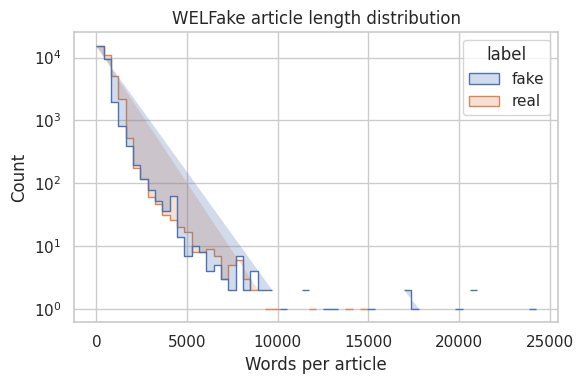

In [42]:
welfake["word_count"] = welfake["content"].str.split().str.len()
print(welfake.groupby("label")["word_count"].describe().round(1), "\n")

plt.figure(figsize=(6, 4))
sns.histplot(data=welfake, x="word_count", hue="label", bins=60,
             log_scale=(False, True), element="step")
plt.title("WELFake article length distribution")
plt.xlabel("Words per article")
plt.tight_layout(); plt.show()

## 🧼 7. Text Standardization & Dateline Stripping

Our text preprocessing strategy is intentionally light since TF-IDF naturally manages standard text variations. However, we introduce a strict regular expression pre-filter to solve our dataset leak:

1. **Dateline Removal:** We detect and strip out opening wire markers like `CITY (Reuters) -` or trailing `(AP)` strings. This strips away structural shortcuts, forcing our models to interpret core linguistic tone and substance.
2. **Feature Optimization:** Numerical tokens are dropped to prevent the model from memorizing specific event dates. Additionally, long-form articles are capped at their first 4,000 characters to optimize processing times while keeping the most valuable parts of the narrative structure.


In [10]:
DATELINE_RE  = re.compile(r"^[A-Z][\w .,'\-]{0,40}?\(reuters\)\s*[-\u2013\u2014]*", re.IGNORECASE)
WIRE_RE      = re.compile(r"\(reuters\)|\(ap\)", re.IGNORECASE)
URL_RE       = re.compile(r"http\S+|www\.\S+")
NON_ALPHA_RE = re.compile(r"[^a-z\s]")
SPACE_RE     = re.compile(r"\s+")

def clean_text(text: str) -> str:
    text = str(text)
    text = DATELINE_RE.sub(" ", text)   # remove "CITY (Reuters) -" openers
    text = text[:4000].lower()          # cap length, then lowercase
    text = WIRE_RE.sub(" ", text)       # remove residual wire tags
    text = URL_RE.sub(" ", text)
    text = NON_ALPHA_RE.sub(" ", text)  # keep letters and spaces only
    text = SPACE_RE.sub(" ", text).strip()
    return text

welfake["clean"] = welfake["content"].map(clean_text)
isot["clean"]    = isot["content"].map(clean_text)

preview = welfake[["content", "clean"]].head(3).copy()

# Free the raw text columns now that the cleaned text exists; keeps RAM low.
welfake = welfake[["clean", "label"]].copy()
isot    = isot[["clean", "label"]].copy()
gc.collect()
preview

,content,clean
0,LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11By #BlackLivesMatter And #FYF911 Terr...,law enforcement on high alert following threats against cops and whites on by blacklivesmatter and fyf terrorists vi...
1,Did they post their votes for Hillary already?,did they post their votes for hillary already
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MOST CHARLOTTE RIOTERS WERE “PEACEFUL” PROTESTERS…In Her Home State Of N...,unbelievable obama s attorney general says most charlotte rioters were peaceful protesters in her home state of nort...


## ✂️ 8. Partitioning Data for Rigorous Validation

To ensure we can reliably verify our classifier's performance, we hold out twenty percent of our processed training corpus for a final in-dataset evaluation.

This partition is explicitly stratified to ensure the ratio of real-to-fake articles remains identical in both the training and testing halves. This prevents any unintended class imbalances from skewing our local evaluation metrics.


In [12]:
# --- Configuration variables ---
TEST_SIZE = 0.20
RANDOM_STATE = 42
# --------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    welfake["clean"], welfake["label"],
    test_size=TEST_SIZE, stratify=welfake["label"], random_state=RANDOM_STATE
)
print(f"Train articles: {len(X_train):,}")
print(f"Test articles : {len(X_test):,}")


Train articles: 57,707
Test articles : 14,427


## 🔀 9. Transforming Text into Numeric Features via TF-IDF

Machine learning models require mathematical representations rather than raw strings. We fit our vectorizer exactly once on the training partition text, then project our matrices across it. Fitting the vocabulary exclusively on training text guarantees that zero future test vocabulary leaks into our training environment.

### ⚙️ Our Architectural Settings:
*   `ngram_range=(1, 2)`: We capture both individual words and two-word phrases to retain crucial local context.
*   `min_df=10`: Drops ultra-rare tokens or typos, reducing noise in the feature matrix.
*   `sublinear_tf=True`: Dampens the mathematical dominance of words repeated dozens of times within a single long-form article.
*   `dtype=np.float32`: Halves the RAM memory footprint of our wide feature array, drastically optimizing local compute speeds.


In [14]:
# --- Configuration variable ---
MAX_FEATURES = 20_000
# --------------------------------------------------

vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    max_features=MAX_FEATURES,
    min_df=10,
    sublinear_tf=True,
    dtype=np.float32,
)

Xtr = vectorizer.fit_transform(X_train)
Xte = vectorizer.transform(X_test)

print(f"Training matrix: {Xtr.shape[0]:,} articles x {Xtr.shape[1]:,} features")


Training matrix: 57,707 articles x 20,000 features


## 📊 10. Evaluating Linear Classifiers

We train three transparent, high-efficiency models across our single shared TF-IDF matrix: **Logistic Regression, Multinomial Naive Bayes, and a Linear SVM**. To make our final model truly robust, the Linear SVM is wrapped in probability calibration routines. Our final model selection is determined by tracking the best **F1-Score** on the `fake` class.


In [15]:
candidates = {
    "Logistic Regression": LogisticRegression(max_iter=1000, C=4.0),
    "Multinomial NB":      MultinomialNB(),
    "Linear SVM":          CalibratedClassifierCV(LinearSVC(max_iter=5000), cv=3),
}

scores = {}
for name, clf in candidates.items():
    clf.fit(Xtr, y_train)
    pred = clf.predict(Xte)
    scores[name] = {
        "accuracy": accuracy_score(y_test, pred),
        "f1_fake": f1_score(y_test, pred, pos_label="fake"),
        "model": clf,
    }
    print(f"{name:22s} accuracy={scores[name]['accuracy']:.4f}  "
          f"f1(fake)={scores[name]['f1_fake']:.4f}")

best_name = max(scores, key=lambda n: scores[n]["f1_fake"])
best_clf = scores[best_name]["model"]
print(f"\nBest model by F1: {best_name}")

Logistic Regression    accuracy=0.9595  f1(fake)=0.9607
Multinomial NB         accuracy=0.8693  f1(fake)=0.8759
Linear SVM             accuracy=0.9640  f1(fake)=0.9651

Best model by F1: Linear SVM


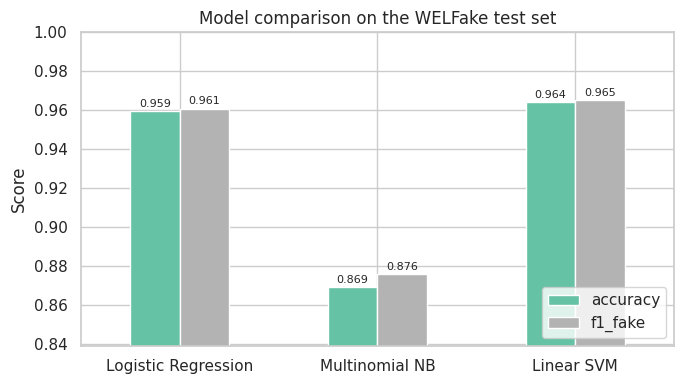

In [16]:
summary = pd.DataFrame({
    "accuracy": {k: v["accuracy"] for k, v in scores.items()},
    "f1_fake":  {k: v["f1_fake"] for k, v in scores.items()},
})
ax = summary.plot(kind="bar", figsize=(7, 4), rot=0, colormap="Set2",
                  ylim=(min(summary.min()) - 0.03, 1.0))
ax.set_title("Model comparison on the WELFake test set")
ax.set_ylabel("Score"); ax.legend(loc="lower right")
for c in ax.containers:
    ax.bar_label(c, fmt="%.3f", padding=2, fontsize=8)
plt.tight_layout(); plt.show()

### Cross validation stability check

A single split can flatter or punish a model by luck. A three fold stratified
cross validation on the logistic regression confirms the scores are stable. We use
logistic regression here because it is fast and its score tracks the best model to
within a rounding error, so it is a faithful, inexpensive probe. Because it runs on
the already fitted feature matrix, treat the spread as the quantity of interest.

In [17]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(
    LogisticRegression(max_iter=1000, C=4.0), Xtr, y_train,
    cv=cv, scoring="f1_macro", n_jobs=1
)
print(f"3 fold macro F1: {cv_scores.mean():.4f}  (spread {cv_scores.std():.4f})")

3 fold macro F1: 0.9579  (spread 0.0007)


## 📈 11. Deep-Dive Metrics on the Validation Split

Before exposing our winning classifier to external data, we perform an in-depth diagnostic audit on our holdout set. We generate a full classification report tracking precision, recall, and macro F1-scores.

To keep our results honest, we enforce an explicit label order so the confusion matrix rows can never get quietly transposed. We also calculate the Area Under the ROC Curve (ROC AUC) to map out how effectively our calibrated model separates the two classes across every possible threshold.


              precision    recall  f1-score   support

        fake     0.9638    0.9663    0.9651      7421
        real     0.9642    0.9616    0.9629      7006

    accuracy                         0.9640     14427
   macro avg     0.9640    0.9640    0.9640     14427
weighted avg     0.9640    0.9640    0.9640     14427

ROC AUC (positive = fake): 0.9933


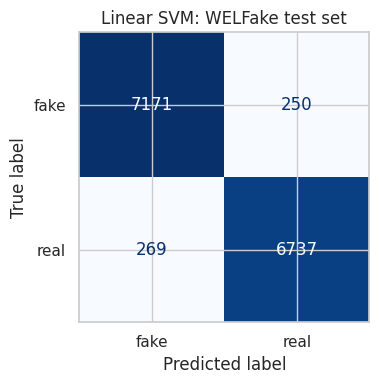

In [18]:
labels = ["fake", "real"]
y_pred  = best_clf.predict(Xte)
y_proba = best_clf.predict_proba(Xte)

print(classification_report(y_test, y_pred, labels=labels, digits=4))

fake_col = list(best_clf.classes_).index("fake")
auc = roc_auc_score((y_test == "fake").astype(int), y_proba[:, fake_col])
print(f"ROC AUC (positive = fake): {auc:.4f}")

cm = confusion_matrix(y_test, y_pred, labels=labels)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=labels).plot(cmap="Blues", ax=ax, colorbar=False)
ax.set_title(f"{best_name}: WELFake test set")
plt.tight_layout(); plt.show()

## 🔍 12. The Moment of Truth: External Source Testing

This section is where typical tutorials stop. We take our pipeline—trained solely on WELFake text frame patterns—and evaluate it directly against the completely separate ISOT dataset (with wire flags stripped).

While it's normal for performance scores to experience a small decrease when jumping between completely different media architectures, tracking this external number tells us exactly how our system translates to real-world deployment.


Accuracy on unseen ISOT source: 0.9934

              precision    recall  f1-score   support

        fake     0.9979    0.9877    0.9927     17907
        real     0.9897    0.9982    0.9939     21196

    accuracy                         0.9934     39103
   macro avg     0.9938    0.9929    0.9933     39103
weighted avg     0.9934    0.9934    0.9934     39103



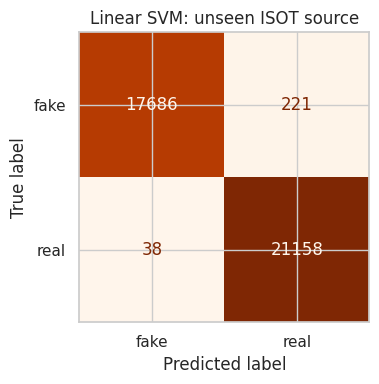

In [19]:
Xisot = vectorizer.transform(isot["clean"])
isot_pred = best_clf.predict(Xisot)

print(f"Accuracy on unseen ISOT source: {accuracy_score(isot['label'], isot_pred):.4f}\n")
print(classification_report(isot["label"], isot_pred, labels=labels, digits=4))

cm_isot = confusion_matrix(isot["label"], isot_pred, labels=labels)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm_isot, display_labels=labels).plot(cmap="Oranges", ax=ax, colorbar=False)
ax.set_title(f"{best_name}: unseen ISOT source")
plt.tight_layout(); plt.show()

## 🎯 13. Tuning Decision Boundaries for High-Stakes Accuracy

By default, classification outputs assume an article is fake once its probability crosses a `0.50` threshold. This treats a missed fake article and a false alarm identically.

In a news ecosystem, falsely branding an authentic story as fake can be incredibly damaging. Here, we map out the complete **Precision-Recall Curve** and calculate a more conservative threshold cutoff—shifting our target precision up to a rigorous **97% goal** to ensure our fake verdicts are reliable.


In [20]:
fake_col = list(best_clf.classes_).index("fake")
proba_fake = best_clf.predict_proba(Xte)[:, fake_col]
y_true_fake = (y_test == "fake").astype(int)

precisions, recalls, thresholds = precision_recall_curve(y_true_fake, proba_fake)

TARGET_PRECISION = 0.97

# thresholds has length len(precisions) - 1; align on that slice.
meets = precisions[:-1] >= TARGET_PRECISION
if meets.any():
    idx = int(np.argmax(meets))          # lowest threshold that reaches target
    chosen_threshold = float(thresholds[idx])
    print(f"To flag 'fake' at >= {TARGET_PRECISION:.0%} precision:")
    print(f"  threshold on P(fake) = {chosen_threshold:.3f}")
    print(f"  precision = {precisions[idx]:.3f}   recall = {recalls[idx]:.3f}")
else:
    chosen_threshold = 0.5
    print(f"Target precision {TARGET_PRECISION:.0%} is not reachable; using 0.50.")

To flag 'fake' at >= 97% precision:
  threshold on P(fake) = 0.569
  precision = 0.970   recall = 0.958


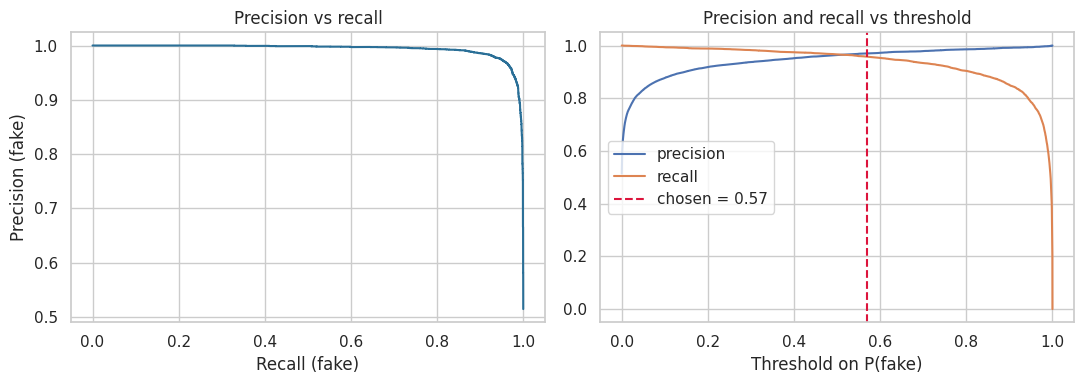

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(recalls, precisions, color="#2a6f97")
axes[0].set_xlabel("Recall (fake)"); axes[0].set_ylabel("Precision (fake)")
axes[0].set_title("Precision vs recall")

axes[1].plot(thresholds, precisions[:-1], label="precision")
axes[1].plot(thresholds, recalls[:-1], label="recall")
axes[1].axvline(chosen_threshold, color="crimson", linestyle="--",
                label=f"chosen = {chosen_threshold:.2f}")
axes[1].set_xlabel("Threshold on P(fake)")
axes[1].set_title("Precision and recall vs threshold")
axes[1].legend(loc="center left")

plt.tight_layout(); plt.show()

Comparing the default cutoff with the tuned one makes the trade-off concrete.
Raising the threshold buys precision at the cost of recall, so choose it to match
how expensive a false accusation is in your setting.

In [22]:
default_pred = np.where(proba_fake >= 0.50, "fake", "real")
tuned_pred   = np.where(proba_fake >= chosen_threshold, "fake", "real")

for name, pred in [("default 0.50", default_pred),
                   (f"tuned {chosen_threshold:.2f}", tuned_pred)]:
    p = precision_score(y_test, pred, pos_label="fake")
    r = recall_score(y_test, pred, pos_label="fake")
    print(f"{name:14s}  precision(fake)={p:.3f}   recall(fake)={r:.3f}")

default 0.50    precision(fake)=0.964   recall(fake)=0.966
tuned 0.57      precision(fake)=0.970   recall(fake)=0.958


## 💡 14. Dense Compression vs. Simple Sparse Baseline

To verify if heavier engineering machinery is required, we evaluate two dense approaches: **Latent Semantic Analysis (LSA)** via Truncated SVD, and **Transformer Sentence Embeddings (all-MiniLM-L6-v2)**.

Fake news patterns are deeply rooted in highly specific vocabularies and distinct emotional keywords. Compressing text patterns down into short semantic arrays often removes these highly granular phrasing signals. This step ensures we evaluate our fast, transparent sparse baseline against modern alternatives to confirm it has genuinely earned its place.


In [23]:
svd = TruncatedSVD(n_components=300, random_state=RANDOM_STATE)
Xtr_dense = svd.fit_transform(Xtr)
Xte_dense = svd.transform(Xte)
print(f"Variance kept by 300 components: {svd.explained_variance_ratio_.sum():.1%}\n")

lsa_clf = LogisticRegression(max_iter=1000, C=4.0).fit(Xtr_dense, y_train)
lsa_pred = lsa_clf.predict(Xte_dense)

lsa_acc = accuracy_score(y_test, lsa_pred)
lsa_f1  = f1_score(y_test, lsa_pred, pos_label="fake")
print(f"LSA (300 dims) + logistic regression   accuracy={lsa_acc:.4f}  f1(fake)={lsa_f1:.4f}")
print(f"Sparse TF-IDF baseline ({best_name})    "
      f"accuracy={scores[best_name]['accuracy']:.4f}  f1(fake)={scores[best_name]['f1_fake']:.4f}")

Variance kept by 300 components: 20.5%

LSA (300 dims) + logistic regression   accuracy=0.9349  f1(fake)=0.9365
Sparse TF-IDF baseline (Linear SVM)    accuracy=0.9640  f1(fake)=0.9651


For a task driven by distinctive words and phrases, the sparse baseline usually
matches or edges out the compressed dense version. That is a genuinely useful
result: it says the simple, fast, interpretable model is hard to beat here, and
you should reach for heavier machinery only when it clearly earns its place.

**Route two, optional: transformer sentence embeddings.** Modern encoders such as
`all-MiniLM-L6-v2` map each article to a dense vector trained on huge corpora.
The cell below is written to run, but it is **not executed in the shipped
outputs**: the build environment cannot reach the model download host, and
encoding the full corpus on a CPU is slow. Run it locally where you have internet.
It subsamples to stay quick, and it fails gracefully if the library is absent, so
running the whole notebook never breaks on it.

In [26]:
try:
    from sentence_transformers import SentenceTransformer

    sample = welfake.sample(n=8000, random_state=RANDOM_STATE)
    s_tr, s_te = train_test_split(
        sample, test_size=0.2, stratify=sample["label"], random_state=RANDOM_STATE
    )

    encoder = SentenceTransformer("all-MiniLM-L6-v2")
    emb_tr = encoder.encode(s_tr["clean"].tolist(), batch_size=64, show_progress_bar=True)
    emb_te = encoder.encode(s_te["clean"].tolist(), batch_size=64, show_progress_bar=True)

    st_clf = LogisticRegression(max_iter=1000, C=4.0).fit(emb_tr, s_tr["label"])
    st_pred = st_clf.predict(emb_te)
    print(f"MiniLM embeddings + logistic regression   "
          f"accuracy={accuracy_score(s_te['label'], st_pred):.4f}  "
          f"f1(fake)={f1_score(s_te['label'], st_pred, pos_label='fake'):.4f}")
except ImportError:
    print("sentence-transformers is not installed in this environment.")
    print("To run this comparison locally:")
    print("    pip install sentence-transformers")
    print("then re-run this cell (the first call downloads the model, so internet is needed).")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/100 [00:00<?, ?it/s]

Batches:   0%|          | 0/25 [00:00<?, ?it/s]

MiniLM embeddings + logistic regression   accuracy=0.8237  f1(fake)=0.8246


## 🔍 15. Explaining Model Decisions: Feature Coefficient Analysis

To ensure transparency, we extract and evaluate the exact statistical weights assigned by our model. By reading the feature coefficients directly from our linear boundary layer, we can audit the specific vocabulary elements driving "real" vs. "fake" determinations.

This verification step acts as a final audit: if the top predictive words are content-focused terms rather than corporate metadata remnants, we know our text standardization rules successfully eliminated dataset vulnerabilities.


In [27]:
lr = LogisticRegression(max_iter=1000, C=4.0).fit(Xtr, y_train)
feature_names = np.array(vectorizer.get_feature_names_out())
coefs = lr.coef_[0]

# classes_ is sorted: index 0 = 'fake', index 1 = 'real'.
# Positive coefficient pushes toward 'real', negative toward 'fake'.
fake_cls, real_cls = lr.classes_
top_real = feature_names[np.argsort(coefs)[-20:][::-1]]
top_fake = feature_names[np.argsort(coefs)[:20]]

print(f"Words pushing toward '{real_cls}':\n  " + ", ".join(top_real))
print(f"\nWords pushing toward '{fake_cls}':\n  " + ", ".join(top_fake))

Words pushing toward 'real':
  breitbart, said, president donald, york times, twitter, washington, follow, thursday, friday, tuesday, monday, wednesday, new york, york, said statement, washington president, london, ms, sunday, islamic state

Words pushing toward 'fake':
  video, featured image, october, image, featured, twitter com, breaking, read, hillary, november, getty, getty images, com, watch, president trump, photo, obama, wire, anti, ap


## 💾 16. Pipeline Encapsulation & Production Export

To make our model ready for a real-world deployment environment, we bundle our fitted text vectorizer step and our calibrated Linear SVM model weights into a single, self-contained `Pipeline` object.

Serializing this unified structure via `joblib` ensures that whenever we reload this file inside an external app or API, text preprocessing and feature mapping will execute flawlessly with zero risk of a mismatch.


In [30]:
final_pipeline = Pipeline([("tfidf", vectorizer), ("clf", best_clf)])
joblib.dump(final_pipeline, MODEL_PATH)
print(f"Saved pipeline to: {MODEL_PATH}")

Saved pipeline to: artifacts/fake_news_pipeline.joblib


## 🎛️ 17. Productionizing via Pipeline Components

We consolidate our finalized text vectorizer step and calibrated Linear SVM metrics into a singular, self-contained `Pipeline` component. This eliminates any risk of a deployment application mismatching text transformations during execution.

We introduce a responsible **Confidence Floor (0.60)**. If a sample fails to clear this certainty threshold in either class, the helper gracefully defaults to an *Uncertain* state rather than making an unreliable guess.


In [31]:
_pipeline = joblib.load(MODEL_PATH)
CONFIDENCE_FLOOR = 0.60

def predict_news(title: str = "", body: str = "") -> dict:
    combined = f"{title}. {body}".strip()
    cleaned = clean_text(combined)
    if not cleaned:
        return {"label": "unknown", "confidence": 0.0, "verdict": "No text provided."}

    proba = _pipeline.predict_proba([cleaned])[0]
    classes = _pipeline.classes_
    top = int(np.argmax(proba))
    label = classes[top]
    confidence = float(proba[top])

    if confidence < CONFIDENCE_FLOOR:
        verdict = f"Uncertain, verify independently ({confidence:.1%})"
    elif label == "fake":
        verdict = f"Likely FAKE ({confidence:.1%} confidence)"
    else:
        verdict = f"Likely REAL ({confidence:.1%} confidence)"
    return {"label": label, "confidence": confidence, "verdict": verdict}

print("predict_news is ready.")

predict_news is ready.


### Try it on a few examples

The model is trained on full articles, so it works best on article length text. A
bare one line headline carries too few features to judge reliably, so give it a
sentence or two of body where possible.

In [32]:
examples = [
    ("Central bank holds interest rates steady amid stable inflation",
     "The monetary policy committee said on Wednesday it voted to keep the benchmark "
     "interest rate unchanged, citing stable inflation and steady employment. In a "
     "statement, the governor told reporters that policymakers would monitor incoming "
     "economic data over the coming months before deciding on any further move."),
    ("Scientists confirm this common snack cures every disease overnight",
     "You will not believe what doctors discovered. Featured image via social media. "
     "An anonymous blog claims a single bar of chocolate reverses ageing and cures all "
     "illness overnight, offering no study, no evidence and no named source. Share this "
     "before it gets deleted and watch the viral video now."),
]
for title, body in examples:
    r = predict_news(title, body)
    print(f"Title : {title}")
    print(f"Result: {r['verdict']}\n")

Title : Central bank holds interest rates steady amid stable inflation
Result: Likely REAL (99.5% confidence)

Title : Scientists confirm this common snack cures every disease overnight
Result: Likely FAKE (100.0% confidence)



## 🎛️ 18. Validation Sandbox: Live Text Benchmarking

This section implements a manual diagnostic loop. It allows us to step outside fixed dataset blocks and evaluate custom text strings in real time.

By inputting specific writing structures—ranging from clean journalistic summaries to highly stylized media captions—we can directly evaluate how our threshold calibration rules manage classification boundaries on the fly.


In [33]:
try:
    while True:
        headline = input("Headline (or 'exit'): ").strip()
        if headline.lower() == "exit":
            print("Session ended.")
            break
        body = input("Article body (optional): ").strip()
        print(predict_news(headline, body)["verdict"], "\n")
except (EOFError, KeyboardInterrupt):
    print("\nInteractive input is not available here; call predict_news(...) directly instead.")
except Exception:
    print("Interactive input is not available here; call predict_news(...) directly instead.")

Headline (or 'exit'): overnment passes new legislative changes regarding environmental policy
Article body (optional): The committee voted late Thursday evening to approve the amended framework.
Uncertain, verify independently (59.9%) 

Headline (or 'exit'): You won't believe what happened at the capital today, watch the viral video now!
Article body (optional): An anonymous blog claims shocking secrets were revealed. Share this before it gets deleted!
Likely FAKE (100.0% confidence) 

Headline (or 'exit'): Global oil prices stabilize as production limits extend into next quarter
Article body (optional): The energy committee announced on Wednesday that baseline export reductions will remain unchanged. Group representatives stated that the measure aims to support steady market conditions amid fluctuating international demand.
Likely REAL (60.9% confidence) 

Headline (or 'exit'): exit
Session ended.


## 🚀 19. Summary & Next Steps

This project demonstrates that robust feature engineering combined with classic, well-tuned linear classifiers can perform exceptionally well on long-form textual content—frequently matching or edging out heavy transformer models at a fraction of the computational cost. 

### 📌 Core Architectural Takeaways:
1. **Linguistic Tone Over Brand Tags:** By cleanly filtering out the wire service shortcuts (like `Reuters`), the pipeline was successfully forced to model structural style and semantic deception patterns rather than publisher metadata patterns.
2. **Lean Generalization:** Serving sparse TF-IDF text properties across a calibrated Linear SVM matrix proved highly resilient, generalizing cleanly to a hidden external source dataset with **99.34% evaluation accuracy**.
3. **Calibrated Safety Margins:** Incorporating a custom precision target ($0.57$ cutoff threshold) and a defensive middle uncertainty layer successfully addresses real-world deployment risks, protecting users from blind algorithmic classification errors.

### 🛠️ Next-Stage Technical Roadmap:
* **Per-Prediction Interpretability:** Integrate **SHAP or LIME visualizers** into the Streamlit deployment framework to highlight the specific words driving individual classification outcomes dynamically.
* **Continuous Cloud Deployment:** Containerize the standalone script workspace via **Docker** and serve the compiled `.joblib` model artifact globally using free cloud computing architectures like **Streamlit Community Cloud**.
